In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import matplotlib.ticker as ticker

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:
odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [4]:

with open(f"{odir}/snap40/mvir/ps-intensity-cent_logM10.pickle", "rb") as f:
    Pk_mean_cent10 = pickle.load(f)
    Pk_cent10 = pickle.load(f)
print("shotnoise", Pk_cent10.attrs["shotnoise"])

shotnoise 201.65155090472237


In [5]:

with open(f"{odir}/snap40/mvir/ps-intensity-sat_logM10.pickle", "rb") as f:
    Pk_mean_sat10 = pickle.load(f)
    Pk_sat10 = pickle.load(f)
print("shotnoise", Pk_sat10.attrs["shotnoise"])

shotnoise 352.6003970113245


In [6]:
ps_type="gal"

In [7]:
def create_shuffled_list0(logM_name, object2shuffle_list):
    interp="tsc"
    object2shuffle = object2shuffle_list[0]
    split_name = ""
    Pk_shuffled_list0 = []
    names_list = []
    seed_i = 0
    seed_f = 100
    n_seed = seed_f - seed_i

    power_list = []
    mean_intensities = []
    snapnum=40

    for seed in range(seed_i,seed_f):
        fname = f"{odir}/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/{ps_type}_ps/shuffle_{object2shuffle}/{logM_name}/{split_name}/seed{seed}.pickle"
        if seed == 0:
            print(fname)
        with open(fname, "rb") as f:
            Pk_mean_gal_shuffled = pickle.load(f)
            #print("mean", Pk_mean_cent_shuffled)
            Pk_gal_shuffled = pickle.load(f)
            #print(Pk_mean_gal_shuffled)
            power_list.append(Pk_gal_shuffled["power"].real)
            
            mean_intensities.append(Pk_mean_gal_shuffled)
            
            print("shotnoise", Pk_gal_shuffled.attrs["shotnoise"])
            Pk_shuffled_list0.append(Pk_gal_shuffled)
            names_list.append(f"seed{seed}")
            

    power_arr = np.array(power_list)
    return Pk_shuffled_list0

In [8]:
def create_shuffled_list1(object2shuffle_list, split_names):
    interp="tsc"
    object2shuffle = object2shuffle_list[0]
    split_name = split_names[0]
    Pk_shuffled_list1 = []
    names_list = []
    seed_i = 0
    seed_f = 100
    n_seed = seed_f - seed_i

    power_list = []
    mean_intensities = []
    snapnum=40

    for seed in range(seed_i,seed_f):
        fname = f"{odir}/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/{ps_type}_ps/shuffle_{object2shuffle}/{logM_name}/{split_name}/seed{seed}.pickle"
        if seed == 0:
            print(fname)
        with open(fname, "rb") as f:
            Pk_mean_gal_shuffled = pickle.load(f)
            #print("mean", Pk_mean_cent_shuffled)
            Pk_gal_shuffled = pickle.load(f)
            #print(Pk_mean_gal_shuffled)
            power_list.append(Pk_gal_shuffled["power"].real)
            
            mean_intensities.append(Pk_mean_gal_shuffled)
            
            print("shotnoise", Pk_gal_shuffled.attrs["shotnoise"])
            Pk_shuffled_list1.append(Pk_gal_shuffled)
            names_list.append(f"seed{seed}")
            

    power_arr = np.array(power_list)
    return Pk_shuffled_list1

In [9]:
def create_shuffled_list2(object2shuffle_list, split_names):
    interp="tsc"

    object2shuffle = object2shuffle_list[1]
    split_name = split_names[1]
    Pk_shuffled_list2 = []
    names_list = []
    seed_i = 0
    seed_f = 100
    n_seed = seed_f - seed_i

    power_list = []
    mean_intensities = []
    snapnum=40
    #logM_name = "logM11-13.8"
    #split_name = "split_nan/dMdyn_split4"
    for seed in range(seed_i,seed_f):
        fname = f"{odir}/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/{ps_type}_ps/shuffle_{object2shuffle}/{logM_name}/{split_name}/seed{seed}.pickle"
        #fname = f"{odir}/snap40/mvir/shuffled/logM10_dlogMdefault.1/{ps_type}_ps/shuffle_{object2shuffle}/shuffle_all/{logM_name}/{split_name}/seed{seed}.pickle"
        
        if seed == 0:
            print(fname)
        with open(fname, "rb") as f:
            Pk_mean_gal_shuffled = pickle.load(f)
            #print("mean", Pk_mean_cent_shuffled)
            Pk_gal_shuffled = pickle.load(f)
            #print(Pk_mean_gal_shuffled)
            power_list.append(Pk_gal_shuffled["power"].real)
            
            mean_intensities.append(Pk_mean_gal_shuffled)
            
            print("shotnoise", Pk_gal_shuffled.attrs["shotnoise"])
            Pk_shuffled_list2.append(Pk_gal_shuffled)
            names_list.append(f"seed{seed}")
            

    power_arr = np.array(power_list)
    return Pk_shuffled_list2

In [10]:
importlib.reload(ps)

<module 'MyHaloPS' from '/cosma/home/dp004/dc-zhan5/MyHaloPS.py'>

In [11]:
def create_shuffled_lists(logM_name, object2shuffle_list, split_names):
    return create_shuffled_list0(logM_name, object2shuffle_list), create_shuffled_list1(object2shuffle_list, split_names), create_shuffled_list2(object2shuffle_list, split_names)

In [12]:
logM_name = "logM12.5-13"
logM_ps_name = ""
ps_type = "gal"
object2shuffle = "gal"
property_name = "conc_proxy"
property_name = "msat_sum"
#property_name = "test"
Nsplits = [2, 4]
#split_name = f"split_nan/{property_name}_split{Nsplit}"
split_names = [f"split_nan/{property_name}_split{Nsplit}" for Nsplit in Nsplits]

object2shuffle_list = [object2shuffle]*2

Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2 = create_shuffled_lists(logM_name, object2shuffle_list, split_names)

../ps_data/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/gal_ps/shuffle_gal/logM12.5-13//seed0.pickle
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.52

shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.52360745197058
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotno

is list
shotnoise:  130.52360745197058
shotnoise:  130.52360745197058
shotnoise:  130.52360745197058
shotnoise:  130.52360745197086
0
1
2


/tmp/ipykernel_3100041/4241166601.py:11: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 1
  leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.65, 1), handlelength=1)
/tmp/ipykernel_3100041/4241166601.py:17: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 1
  leg = ax.legend(handles=color_leg[2:], labels=[rf"$M_{{\rm sat}}$ ({Nsplits[1]})"], loc='upper left', bbox_to_anchor=(0.65, 0.73), handlelength=1)
/tmp/ipykernel_3100041/4241166601.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


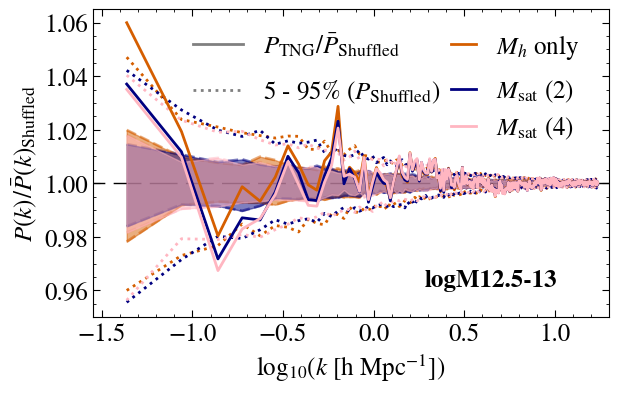

In [13]:
color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2], percentiles=[25,5], labels=[f"Shuffle {object2shuffle} {logM_name}", f"4 percentiles", f"100 percentiles", "Shuffled quartiles"], ratio_ylabel_list=["Shuffled",""], return_color_leg=True, tng_shuffle_type="property")#, bbox_to_anchor_color = (0,0.8))
#plt.ylim(0.97,1.06)
ax = plt.gca()
 
solid_line = Line2D([],[],color="grey", linestyle="solid")
leg = ax.legend(handles=[solid_line], labels=[r"$P_{\rm TNG}/\bar{P}_{\rm Shuffled}$"], loc='upper left', bbox_to_anchor=(0.15, 1))
ax.add_artist(leg)
dot_line = Line2D([],[],color="grey", linestyle="dotted")
leg = ax.legend(handles=[dot_line], labels=[r"5 - 95% $(P_{\rm Shuffled})$"], loc='upper left', bbox_to_anchor=(0.15, 0.85))
ax.add_artist(leg)
leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.65, 1), handlelength=1)
ax.add_artist(leg)

#ax.annotate(r"$\rm \widetilde{V}_{max}$", (0.65,0.73), xycoords="figure fraction")
leg = ax.legend(handles=color_leg[1:2], labels=[rf"$M_{{\rm sat}}$ ({Nsplits[0]})"], loc='upper left', bbox_to_anchor=(0.65, 0.85), handlelength=1)
ax.add_artist(leg)
leg = ax.legend(handles=color_leg[2:], labels=[rf"$M_{{\rm sat}}$ ({Nsplits[1]})"], loc='upper left', bbox_to_anchor=(0.65, 0.73), handlelength=1)
ax.add_artist(leg)
#ax.annotate(r"M$\rm_{vir}$ &",(0.9,0.1), xycoords="axes fraction")
#ax.annotate(r"Split by $\rm \tilde{V}_{max}$", (0.87,0.85), xycoords="axes fraction", ha="right")
#ax.annotate(r"Split by $\rm M_{sat}$", (0.9,0.85), xycoords="axes fraction", ha="right")

ax.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")
#ax.annotate(r"$\mathbf{log}\ \boldsymbol{M}_\boldsymbol{h} \boldsymbol{12.5-13}$", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")
#ax.annotate(r"$\mathbf{log}\ \boldsymbol{M} \boldsymbol{12.5-13}$", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")


plt.ylim(0.95,1.065)
plt.legend()
plt.savefig("../figures/logM12.5-13_msat_split.pdf", format="pdf", bbox_inches="tight")

In [14]:
logM_name = "logM12-12.5"
logM_ps_name = ""
ps_type = "gal"
object2shuffle = "gal"
property_name = "conc_proxy"
property_name = "msat_sum"
#property_name = "test"
Nsplits = [2, 4]
#split_name = f"split_nan/{property_name}_split{Nsplit}"
split_names = [f"split_nan/{property_name}_split{Nsplit}" for Nsplit in Nsplits]

object2shuffle_list = [object2shuffle]*2


Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2 = create_shuffled_lists(logM_name, object2shuffle_list, split_names)

../ps_data/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/gal_ps/shuffle_gal/logM12-12.5//seed0.pickle
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197075
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197075
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197075
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.5236074519

is list
shotnoise:  130.52360745197075
shotnoise:  130.52360745197075
shotnoise:  130.52360745197075
shotnoise:  130.52360745197086
0
1
2


/tmp/ipykernel_3100041/2419598930.py:11: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 1
  leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.65, 1), handlelength=1)
/tmp/ipykernel_3100041/2419598930.py:17: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 1
  leg = ax.legend(handles=color_leg[2:], labels=[rf"$M_{{\rm sat}}$ ({Nsplits[1]})"], loc='upper left', bbox_to_anchor=(0.65, 0.73), handlelength=1)
/tmp/ipykernel_3100041/2419598930.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


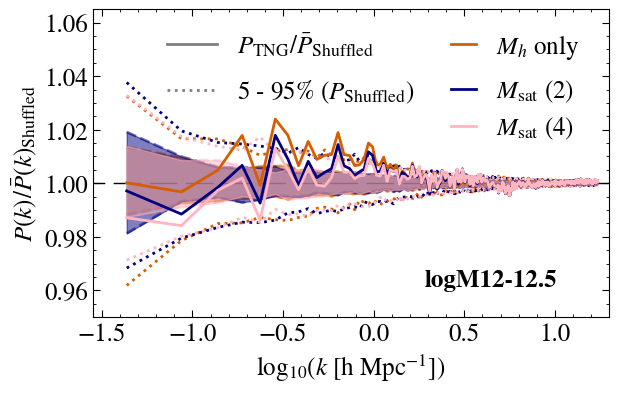

In [15]:
color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2], percentiles=[25,5], labels=[f"Shuffle {object2shuffle} {logM_name}", f"4 percentiles", f"100 percentiles", "Shuffled quartiles"], ratio_ylabel_list=["Shuffled",""], return_color_leg=True, tng_shuffle_type="property")#, bbox_to_anchor_color = (0,0.8))
#plt.ylim(0.97,1.06)
ax = plt.gca()
 
solid_line = Line2D([],[],color="grey", linestyle="solid")
leg = ax.legend(handles=[solid_line], labels=[r"$P_{\rm TNG}/\bar{P}_{\rm Shuffled}$"], loc='upper left', bbox_to_anchor=(0.1, 1))
ax.add_artist(leg)
dot_line = Line2D([],[],color="grey", linestyle="dotted")
leg = ax.legend(handles=[dot_line], labels=[r"5 - 95% $(P_{\rm Shuffled})$"], loc='upper left', bbox_to_anchor=(0.1, 0.85))
ax.add_artist(leg)
leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.65, 1), handlelength=1)
ax.add_artist(leg)

#ax.annotate(r"$\rm \widetilde{V}_{max}$", (0.65,0.73), xycoords="figure fraction")
leg = ax.legend(handles=color_leg[1:2], labels=[rf"$M_{{\rm sat}}$ ({Nsplits[0]})"], loc='upper left', bbox_to_anchor=(0.65, 0.85), handlelength=1)
ax.add_artist(leg)
leg = ax.legend(handles=color_leg[2:], labels=[rf"$M_{{\rm sat}}$ ({Nsplits[1]})"], loc='upper left', bbox_to_anchor=(0.65, 0.73), handlelength=1)
ax.add_artist(leg)
#ax.annotate(r"M$\rm_{vir}$ &",(0.9,0.1), xycoords="axes fraction")
#ax.annotate(r"Split by $\rm \tilde{V}_{max}$", (0.87,0.85), xycoords="axes fraction", ha="right")
#ax.annotate(r"Split by $\rm M_{sat}$", (0.9,0.85), xycoords="axes fraction", ha="right")

ax.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")

plt.ylim(0.95,1.065)
plt.legend()
plt.savefig("../figures/logM12-12.5_msat_split.pdf", format="pdf", bbox_inches="tight")


In [16]:
logM_name = "logM11.5-12"
object2shuffle_list = ["gal", "cent_sat"]
property_name = "conc_proxy"
property_name2 = "msat_sum"
Nsplit = 4
split_name1 = f"split_nan/{property_name}_split{Nsplit}/{property_name2}_split{Nsplit}"
split_name2 = f"{property_name}_split{Nsplit}_{property_name2}_split{Nsplit}"
split_names = [split_name1, split_name2]


Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2 = create_shuffled_lists(logM_name, object2shuffle_list, split_names)

../ps_data/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/gal_ps/shuffle_gal/logM11.5-12//seed0.pickle
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.5236074519706
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.5236074519706
shotnoise 130.5236074519706
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.5236074519706
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072
shotnoise 130.52360745197072

is list
shotnoise:  130.52360745197072
shotnoise:  130.52360745197072
shotnoise:  130.52360745197075
shotnoise:  130.52360745197086
0
1
2


/tmp/ipykernel_3100041/3852443658.py:11: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 1
  leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.55, 1), handlelength=1)
/tmp/ipykernel_3100041/3852443658.py:17: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 1
  leg = ax.legend(handles=color_leg[2:], labels=[rf"Cent & Sat"], loc='upper left', bbox_to_anchor=(0.55, 0.63), handlelength=1)
/tmp/ipykernel_3100041/3852443658.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


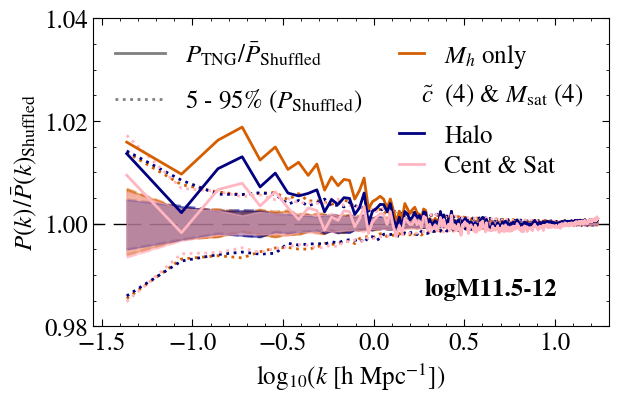

In [17]:
color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2], percentiles=[25,5], labels=[f"Shuffle {object2shuffle} {logM_name}", f"4 percentiles", f"100 percentiles", "Shuffled quartiles"], ratio_ylabel_list=["Shuffled",""], return_color_leg=True, tng_shuffle_type="property")#, bbox_to_anchor_color = (0,0.8))
#plt.ylim(0.97,1.06)
ax = plt.gca()
 
solid_line = Line2D([],[],color="grey", linestyle="solid")
leg = ax.legend(handles=[solid_line], labels=[r"$P_{\rm TNG}/\bar{P}_{\rm Shuffled}$"], loc='upper left', bbox_to_anchor=(0, 1))
ax.add_artist(leg)
dot_line = Line2D([],[],color="grey", linestyle="dotted")
leg = ax.legend(handles=[dot_line], labels=[r"5 - 95% $(P_{\rm Shuffled})$"], loc='upper left', bbox_to_anchor=(0, 0.85))
ax.add_artist(leg)
leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.55, 1), handlelength=1)
ax.add_artist(leg)

ax.annotate(r"$\tilde{c}$  (4)"+ r" & $ M_{\rm sat}$ (4)", (0.95,0.73), xycoords="axes fraction", ha="right")
leg = ax.legend(handles=color_leg[1:2], labels=[rf"Halo"], loc='upper left', bbox_to_anchor=(0.55, 0.73), handlelength=1)
ax.add_artist(leg)
leg = ax.legend(handles=color_leg[2:], labels=[rf"Cent & Sat"], loc='upper left', bbox_to_anchor=(0.55, 0.63), handlelength=1)
ax.add_artist(leg)
#ax.annotate(r"M$\rm_{vir}$ &",(0.9,0.1), xycoords="axes fraction")
#ax.annotate(r"Split by $\rm \tilde{V}_{max}$", (0.87,0.85), xycoords="axes fraction", ha="right")
#ax.annotate(r"Split by $\rm M_{sat}$", (0.9,0.85), xycoords="axes fraction", ha="right")

ax.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")

plt.ylim(0.98,1.04)
plt.legend()
plt.savefig("../figures/logM11.5-12_together_vs_separate.pdf", format="pdf", bbox_inches="tight")

In [18]:
logM_name = "logM11-11.5"
logM_ps_name = ""
ps_type = "gal"
object2shuffle = "gal"
property_name = "conc_proxy"
#property_name = "msat_sum"
#property_name = "test"
Nsplits = [4, 100]
#split_name = f"split_nan/{property_name}_split{Nsplit}"
split_names = [f"split_nan/{property_name}_split{Nsplit}" for Nsplit in Nsplits]

object2shuffle_list = [object2shuffle]*2


Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2 = create_shuffled_lists(logM_name, object2shuffle_list, split_names)

../ps_data/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/gal_ps/shuffle_gal/logM11-11.5//seed0.pickle
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197058
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197058
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197058
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197058
shotnoise 130.5236074519

shotnoise 130.52360745197058
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197058
shotnoise 130.52360745197058
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197063
shotnoise 130.52360745197058
shotnoise 130.52360745197063
shotnoise 130.

is list
shotnoise:  130.52360745197066
shotnoise:  130.52360745197063
shotnoise:  130.52360745197066
shotnoise:  130.52360745197086
0
1
2


/tmp/ipykernel_3100041/3762665543.py:11: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 1
  leg = ax.legend(handles=color_leg, labels=[r"$M_{h}$ only"], loc='upper left', bbox_to_anchor=(0.6, 1), handlelength=1)
/tmp/ipykernel_3100041/3762665543.py:17: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 1
  leg = ax.legend(handles=color_leg[2:], labels=[rf"$\tilde{{c}}$   ({Nsplits[1]})"], loc='upper left', bbox_to_anchor=(0.6, 0.73), handlelength=1)
/tmp/ipykernel_3100041/3762665543.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


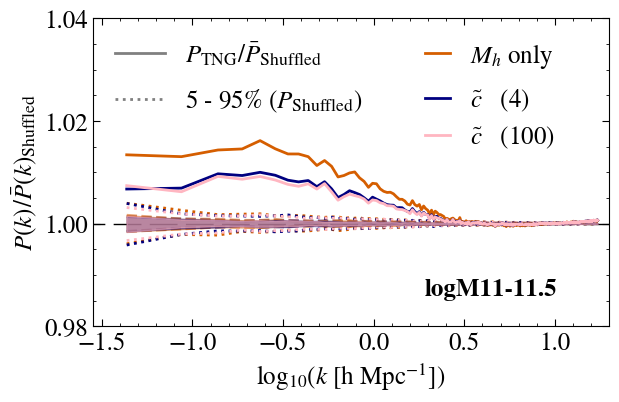

In [19]:
color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2], percentiles=[25,5], labels=[f"Shuffle {object2shuffle} {logM_name}", f"4 percentiles", f"100 percentiles", "Shuffled quartiles"], ratio_ylabel_list=["Shuffled",""], return_color_leg=True, tng_shuffle_type="property")#, bbox_to_anchor_color = (0,0.8))
#plt.ylim(0.97,1.06)
ax = plt.gca()
 
solid_line = Line2D([],[],color="grey", linestyle="solid")
leg = ax.legend(handles=[solid_line], labels=[r"$P_{\rm TNG}/\bar{P}_{\rm Shuffled}$"], loc='upper left', bbox_to_anchor=(0, 1))
ax.add_artist(leg)
dot_line = Line2D([],[],color="grey", linestyle="dotted")
leg = ax.legend(handles=[dot_line], labels=[r"5 - 95% $(P_{\rm Shuffled})$"], loc='upper left', bbox_to_anchor=(0, 0.85))
ax.add_artist(leg)
leg = ax.legend(handles=color_leg, labels=[r"$M_{h}$ only"], loc='upper left', bbox_to_anchor=(0.6, 1), handlelength=1)
ax.add_artist(leg)

#ax.annotate(r"$\rm \widetilde{V}_{max}$", (0.65,0.73), xycoords="figure fraction")
leg = ax.legend(handles=color_leg[1:2], labels=[rf"$\tilde{{c}}$   ({Nsplits[0]})"], loc='upper left', bbox_to_anchor=(0.6, 0.85), handlelength=1)
ax.add_artist(leg)
leg = ax.legend(handles=color_leg[2:], labels=[rf"$\tilde{{c}}$   ({Nsplits[1]})"], loc='upper left', bbox_to_anchor=(0.6, 0.73), handlelength=1)
ax.add_artist(leg)
#ax.annotate(r"M$\rm_{vir}$ &",(0.9,0.1), xycoords="axes fraction")
#ax.annotate(r"Split by $\rm \tilde{V}_{max}$", (0.87,0.85), xycoords="axes fraction", ha="right")
#ax.annotate(r"Split by $\rm M_{sat}$", (0.9,0.85), xycoords="axes fraction", ha="right")

ax.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")

plt.ylim(0.98,1.04)
plt.legend()
plt.savefig("../figures/logM11-11.5_conc_proxy_split.pdf", format="pdf", bbox_inches="tight")


In [27]:
logM_name = "logM11-13.8"
logM_ps_name = ""
ps_type = "sat"
object2shuffle = "sat"
#property_name = "conc_proxy"
property_name = "msat_sum"
#property_name = "dMdyn"
#property_name = "test"
Nsplits = [2, 4]
#split_name = f"split_nan/{property_name}_split{Nsplit}"
Nsplit=4
#split_names = [f"split_nan/{property_name}_split{Nsplit}/{property_name2}_split{Nsplit}"]
split_names = [f"split_nan/{property_name}_split{Nsplit}" for Nsplit in Nsplits]
Nsplit = 4
#property_names = ["dMdyn","msat_sum"]
#split_names = [f"{property_name}_split{Nsplit}" for property_name in property_names]
object2shuffle_list = [object2shuffle]*2


Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2 = create_shuffled_lists(logM_name, object2shuffle_list, split_names)


../ps_data/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/sat_ps/shuffle_sat/logM11-13.8//seed0.pickle
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.600397011324

shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.6003970113244
shotnoise 352.600397

is list
shotnoise:  352.60039701132433
shotnoise:  352.60039701132433
shotnoise:  352.60039701132433
shotnoise:  352.6003970113245
0
1
2


/tmp/ipykernel_1799540/2086788168.py:11: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 1
  leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.65, 1), handlelength=1)
/tmp/ipykernel_1799540/2086788168.py:16: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 1
  leg = ax.legend(handles=color_leg[2:], labels=[rf"$M_{{\rm sat}}$ ({Nsplits[1]})"], loc='upper left', bbox_to_anchor=(0.65, 0.73), handlelength=1)
/tmp/ipykernel_1799540/2086788168.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


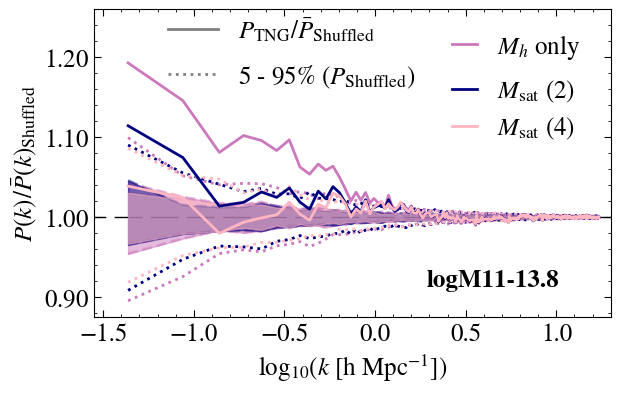

In [29]:
color_leg = ps.residual_plot([Pk_sat10], mean_of_seeds_lists=[Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2], percentiles=[25,5], labels=[f"Shuffle {object2shuffle} {logM_name}", f"4 percentiles", f"100 percentiles", "Shuffled quartiles"], ratio_ylabel_list=["Shuffled",""], return_color_leg=True, tng_shuffle_type="property", ps_type=ps_type)#, bbox_to_anchor_color = (0,0.8))
#plt.ylim(0.97,1.06)
ax = plt.gca()

solid_line = Line2D([],[],color="grey", linestyle="solid")
leg = ax.legend(handles=[solid_line], labels=[r"$P_{\rm TNG}/\bar{P}_{\rm Shuffled}$"], loc='upper left', bbox_to_anchor=(0.1, 1.05))
ax.add_artist(leg)
dot_line = Line2D([],[],color="grey", linestyle="dotted")
leg = ax.legend(handles=[dot_line], labels=[r"5 - 95% $(P_{\rm Shuffled})$"], loc='upper left', bbox_to_anchor=(0.1, 0.9))
ax.add_artist(leg)
leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.65, 1), handlelength=1)
ax.add_artist(leg)
 
leg = ax.legend(handles=color_leg[1:2], labels=[rf"$M_{{\rm sat}}$ ({Nsplits[0]})"], loc='upper left', bbox_to_anchor=(0.65, 0.85), handlelength=1)
ax.add_artist(leg)
leg = ax.legend(handles=color_leg[2:], labels=[rf"$M_{{\rm sat}}$ ({Nsplits[1]})"], loc='upper left', bbox_to_anchor=(0.65, 0.73), handlelength=1)
ax.add_artist(leg)
# leg = ax.legend(handles=color_leg, labels=["Shuffle by"+ "\n" + r"$M\rm_{vir}$ only"], loc='upper left', bbox_to_anchor=(0.1, 1))
# ax.add_artist(leg)
# leg = ax.legend(handles=color_leg[1:2], labels=[fr"{Nsplits[0]} percentiles"], loc='upper left', bbox_to_anchor=(0.5, 0.85
#                                                                                             ))
# ax.add_artist(leg)
# leg = ax.legend(handles=color_leg[2:], labels=[fr"{Nsplits[1]} percentiles"], loc='upper left', bbox_to_anchor=(0.5, 0.73))
# ax.add_artist(leg)
# #ax.annotate(r"M$\rm_{vir}$ &",(0.9,0.1), xycoords="axes fraction")
# #ax.annotate(r"Split by $\rm \tilde{V}_{max}$", (0.87,0.85), xycoords="axes fraction", ha="right")
# ax.annotate(r"Split by $M_{\rm sat}$", (0.9,0.85), xycoords="axes fraction", ha="right")

ax.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:.2f}$'))
plt.ylim(0.875,1.26)
plt.legend()
plt.savefig("../figures/logM11-13.8_msat_sat_ps.pdf", format="pdf", bbox_inches="tight")


In [20]:
logM_name = "logM11-13.8"
logM_ps_name = ""
ps_type = "gal"
object2shuffle1 = "gal"
object2shuffle2 = "gal,cent_sat"
property_name = "msat_sum"

#Nsplits = [4]
Nsplit = 4

split_name1 = f"split_nan/{property_name}_split{Nsplit}"
split_name2 = f"/logM11-11.5,logM12-13.8,logM11.5-12/conc_proxy_split2,msat_sum_split4,conc_proxy_split4_msat_sum_split4"
split_names = [split_name1, split_name2]

object2shuffle_list = [object2shuffle1, object2shuffle2]

In [21]:

Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2 = create_shuffled_lists(logM_name, object2shuffle_list, split_names)

../ps_data/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/gal_ps/shuffle_gal/logM11-13.8//seed0.pickle
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.5236074519707
shotnoise 130.5236074519707
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197078
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.5236074519707
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.5236074519707
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.5236074519707
shotnoise 130.52360745197075
shotnoise 130.5236074519707
shotnoise 130.52360745197075
s

shotnoise 130.52360745197075
shotnoise 130.52360745197078
shotnoise 130.52360745197075
shotnoise 130.52360745197072
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197078
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197078
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197078
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.5236074519707
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52360745197072
shotnoise 130.5236074519707
shotnoise 130.52360745197075
shotnoise 130.52360745197075
shotnoise 130.52

is list
shotnoise:  130.52360745197075
shotnoise:  130.52360745197075
shotnoise:  130.52360745197058
shotnoise:  130.52360745197086
0
1
2


/tmp/ipykernel_3100041/78761516.py:21: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 1
  leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.65, 1), handlelength=1)
/tmp/ipykernel_3100041/78761516.py:27: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 1
  leg = ax.legend(handles=color_leg[2:], labels=[rf"various"], loc='upper left', bbox_to_anchor=(0.65, 0.73), handlelength=1)
/tmp/ipykernel_3100041/78761516.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


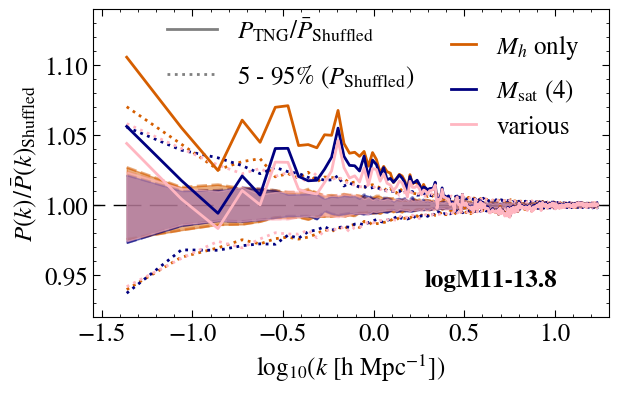

In [22]:
color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list, Pk_shuffled_list1, Pk_shuffled_list2], percentiles=[25,5], labels=[f"", f"4 percentiles", f"100 percentiles", "Shuffled quartiles"], ratio_ylabel_list=["Shuffled",""], return_color_leg=True, tng_shuffle_type="property")#, bbox_to_anchor_color = (0,0.8))
#plt.ylim(0.97,1.06)
ax = plt.gca()
 
# leg = ax.legend(handles=color_leg, labels=["Shuffle by"+ "\n" + r"$M\rm_{vir}$ only"], loc='upper left', bbox_to_anchor=(0.1, 1))
# ax.add_artist(leg)
# leg = ax.legend(handles=color_leg[1:2], labels=[fr"$M_{{\mathrm{{sat}}}}$ (4)"], loc='upper left', bbox_to_anchor=(0.6, 0.85
#                                                                                             ))
# ax.add_artist(leg)
# leg = ax.legend(handles=color_leg[2:], labels=[fr"various"], loc='upper left', bbox_to_anchor=(0.6, 0.73))
# ax.add_artist(leg)
# #ax.annotate(r"M$\rm_{vir}$ &",(0.9,0.1), xycoords="axes fraction")
# #ax.annotate(r"Split by $\rm V_{max}/r_{max}$ (6)", (0.95,0.9), xycoords="axes fraction", ha="right")
# ax.annotate(r"Split by", (0.9,0.85), xycoords="axes fraction", ha="right")
solid_line = Line2D([],[],color="grey", linestyle="solid")
leg = ax.legend(handles=[solid_line], labels=[r"$P_{\rm TNG}/\bar{P}_{\rm Shuffled}$"], loc='upper left', bbox_to_anchor=(0.1, 1.05))
ax.add_artist(leg)
dot_line = Line2D([],[],color="grey", linestyle="dotted")
leg = ax.legend(handles=[dot_line], labels=[r"5 - 95% $(P_{\rm Shuffled})$"], loc='upper left', bbox_to_anchor=(0.1, 0.9))
ax.add_artist(leg)
leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.65, 1), handlelength=1)
ax.add_artist(leg)

#ax.annotate(r"$\rm \widetilde{V}_{max}$", (0.65,0.73), xycoords="figure fraction")
leg = ax.legend(handles=color_leg[1:2], labels=[rf"$M_{{\rm sat}}$ (4)"], loc='upper left', bbox_to_anchor=(0.65, 0.85), handlelength=1)
ax.add_artist(leg)
leg = ax.legend(handles=color_leg[2:], labels=[rf"various"], loc='upper left', bbox_to_anchor=(0.65, 0.73), handlelength=1)
ax.add_artist(leg)

ax.annotate(f"logM11-13.8", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")

plt.ylim(0.92,1.14)
plt.legend()
plt.savefig("../figures/logM11-13.8_various_vs_msat_4.pdf", format="pdf", bbox_inches="tight")


is list
shotnoise:  130.52360745197075
shotnoise:  130.52360745197058
shotnoise:  130.52360745197058
shotnoise:  130.52360745197086
0
1
2


/tmp/ipykernel_3100041/2865602989.py:12: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 1
  leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.55, 1), handlelength=1)
/tmp/ipykernel_3100041/2865602989.py:18: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 1
  leg = ax.legend(handles=color_leg[2:], labels=[rf"+ 2 properties"], loc='upper left', bbox_to_anchor=(0.55, 0.73), handlelength=1)
/tmp/ipykernel_3100041/2865602989.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


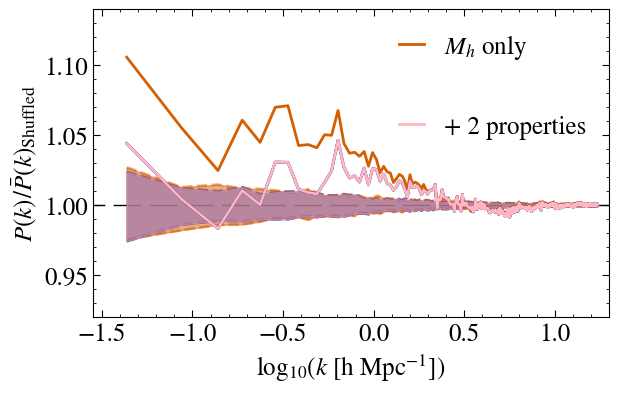

In [23]:
color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list, Pk_shuffled_list2, Pk_shuffled_list2], percentiles=[25], labels=[f"", f"4 percentiles", f"100 percentiles", "Shuffled quartiles"], ratio_ylabel_list=["Shuffled",""], return_color_leg=True, tng_shuffle_type="property")#, bbox_to_anchor_color = (0,0.8))
#plt.ylim(0.97,1.06)
ax = plt.gca()
 

solid_line = Line2D([],[],color="grey", linestyle="solid")
# leg = ax.legend(handles=[solid_line], labels=[r"$P_{\rm TNG}/\bar{P}_{\rm Shuffled}$"], loc='upper left', bbox_to_anchor=(0.1, 1.05))
# ax.add_artist(leg)
dot_line = Line2D([],[],color="grey", linestyle="dotted")
# leg = ax.legend(handles=[dot_line], labels=[r"5 - 95% $(P_{\rm Shuffled})$"], loc='upper left', bbox_to_anchor=(0.1, 0.9))
# ax.add_artist(leg)
leg = ax.legend(handles=color_leg, labels=[r"$M_h$ only"], loc='upper left', bbox_to_anchor=(0.55, 1), handlelength=1)
ax.add_artist(leg)

#ax.annotate(r"$\rm \widetilde{V}_{max}$", (0.65,0.73), xycoords="figure fraction")
# leg = ax.legend(handles=color_leg[1:2], labels=[rf"$M_{{\rm sat}}$ (4)"], loc='upper left', bbox_to_anchor=(0.65, 0.85), handlelength=1)
# ax.add_artist(leg)
leg = ax.legend(handles=color_leg[2:], labels=[rf"+ 2 properties"], loc='upper left', bbox_to_anchor=(0.55, 0.73), handlelength=1)
ax.add_artist(leg)

#ax.annotate(f"logM11-13.8", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")

plt.ylim(0.92,1.14)
plt.legend()


is list
shotnoise:  130.52360745197075
shotnoise:  130.52360745197058
shotnoise:  130.52360745197058
shotnoise:  130.52360745197086
0
1
2


<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3100041/1564987928.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("波数 $\log_{10} k$", fontproperties=jp_prop, labelpad=2)
/tmp/ipykernel_3100041/1564987928.py:17: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 1
  leg1 = ax.legend(handles=color_leg, labels=[r"質量のみモデル"], loc='upper left', bbox_to_anchor=(0.4, 1), handlelength=1)
/tmp/ipykernel_3100041/1564987928.py:24: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 1
  leg2 = ax.legend(handles=color_leg[2:], labels=[rf"２つの特性を加えた場合"], loc='lower left', bbox_to_anchor=(0, 0), handlelength=1)
/tmp/ipykernel_3100041/1564987928.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, '波数 $\\log_{10} k$')

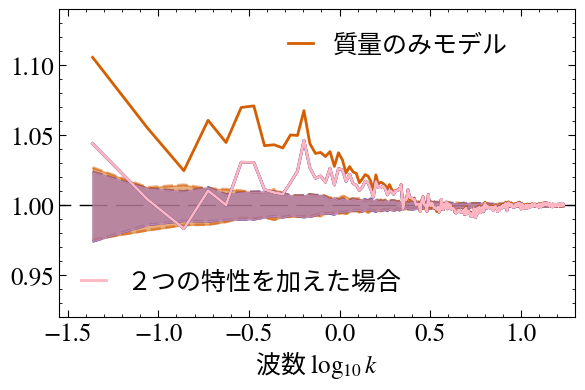

In [24]:
import matplotlib.font_manager as fm

jp_font_path = '/cosma/home/dp004/dc-zhan5/NotoSansCJKjp-Regular.otf'
jp_prop = fm.FontProperties(fname=jp_font_path)

color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list, Pk_shuffled_list2, Pk_shuffled_list2], percentiles=[25], labels=[f"", f"4 percentiles", f"100 percentiles", "Shuffled quartiles"], ratio_ylabel_list=["Shuffled",""], return_color_leg=True, tng_shuffle_type="property")#, bbox_to_anchor_color = (0,0.8))
#plt.ylim(0.97,1.06)
ax = plt.gca()
 

solid_line = Line2D([],[],color="grey", linestyle="solid")
# leg = ax.legend(handles=[solid_line], labels=[r"$P_{\rm TNG}/\bar{P}_{\rm Shuffled}$"], loc='upper left', bbox_to_anchor=(0.1, 1.05))
# ax.add_artist(leg)
dot_line = Line2D([],[],color="grey", linestyle="dotted")
# leg = ax.legend(handles=[dot_line], labels=[r"5 - 95% $(P_{\rm Shuffled})$"], loc='upper left', bbox_to_anchor=(0.1, 0.9))
# ax.add_artist(leg)
leg1 = ax.legend(handles=color_leg, labels=[r"質量のみモデル"], loc='upper left', bbox_to_anchor=(0.4, 1), handlelength=1)
ax.add_artist(leg1)


#ax.annotate(r"$\rm \widetilde{V}_{max}$", (0.65,0.73), xycoords="figure fraction")
# leg = ax.legend(handles=color_leg[1:2], labels=[rf"$M_{{\rm sat}}$ (4)"], loc='upper left', bbox_to_anchor=(0.65, 0.85), handlelength=1)
# ax.add_artist(leg)
leg2 = ax.legend(handles=color_leg[2:], labels=[rf"２つの特性を加えた場合"], loc='lower left', bbox_to_anchor=(0, 0), handlelength=1)
ax.add_artist(leg2)

for leg in [leg1, leg2]:
    plt.setp(leg.get_title(), fontproperties=jp_prop) # Sets the title font
    for text in leg.get_texts():
        plt.setp(text, fontproperties=jp_prop)        # Sets the label fonts

#ax.annotate(f"logM11-13.8", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")

plt.ylim(0.92,1.14)
plt.legend()
ax.set_ylabel("", fontproperties=jp_prop, labelpad=2)

ax.set_xlabel("波数 $\log_{10} k$", fontproperties=jp_prop, labelpad=2)

is list
shotnoise:  130.52360745197075
shotnoise:  130.52360745197058
shotnoise:  130.52360745197058
shotnoise:  130.52360745197086
0
1
2


<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3100041/1387764930.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("Wavenumber $\log_{10} k$", fontproperties=jp_prop, labelpad=2)
/tmp/ipykernel_3100041/1387764930.py:17: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 1
  leg1 = ax.legend(handles=color_leg, labels=[r"Mass-only model"], loc='upper left', bbox_to_anchor=(0.4, 1), handlelength=1)
/tmp/ipykernel_3100041/1387764930.py:24: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 1
  leg2 = ax.legend(handles=color_leg[2:], labels=[rf"Adding 2 properties I found"], loc='lower left', bbox_to_anchor=(0, 0), handlelength=1)
/tmp/ipykernel_3100041/1387764930.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

Text(0.5, 0, 'Wavenumber $\\log_{10} k$')

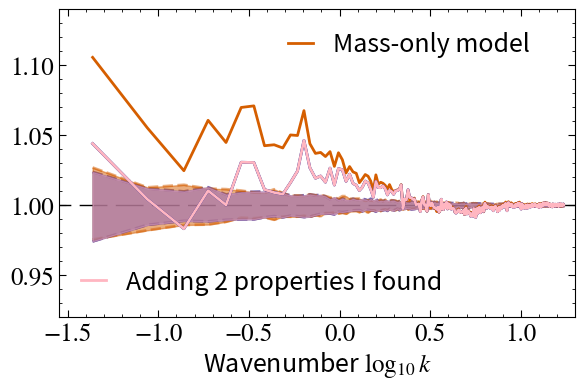

In [27]:
import matplotlib.font_manager as fm

jp_font_path = '/cosma/home/dp004/dc-zhan5/NotoSansCJKjp-Regular.otf'
jp_prop = fm.FontProperties(fname=jp_font_path)

color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list, Pk_shuffled_list2, Pk_shuffled_list2], percentiles=[25], labels=[f"", f"4 percentiles", f"100 percentiles", "Shuffled quartiles"], ratio_ylabel_list=["Shuffled",""], return_color_leg=True, tng_shuffle_type="property")#, bbox_to_anchor_color = (0,0.8))
#plt.ylim(0.97,1.06)
ax = plt.gca()
 

solid_line = Line2D([],[],color="grey", linestyle="solid")
# leg = ax.legend(handles=[solid_line], labels=[r"$P_{\rm TNG}/\bar{P}_{\rm Shuffled}$"], loc='upper left', bbox_to_anchor=(0.1, 1.05))
# ax.add_artist(leg)
dot_line = Line2D([],[],color="grey", linestyle="dotted")
# leg = ax.legend(handles=[dot_line], labels=[r"5 - 95% $(P_{\rm Shuffled})$"], loc='upper left', bbox_to_anchor=(0.1, 0.9))
# ax.add_artist(leg)
leg1 = ax.legend(handles=color_leg, labels=[r"Mass-only model"], loc='upper left', bbox_to_anchor=(0.4, 1), handlelength=1)
ax.add_artist(leg1)


#ax.annotate(r"$\rm \widetilde{V}_{max}$", (0.65,0.73), xycoords="figure fraction")
# leg = ax.legend(handles=color_leg[1:2], labels=[rf"$M_{{\rm sat}}$ (4)"], loc='upper left', bbox_to_anchor=(0.65, 0.85), handlelength=1)
# ax.add_artist(leg)
leg2 = ax.legend(handles=color_leg[2:], labels=[rf"Adding 2 properties I found"], loc='lower left', bbox_to_anchor=(0, 0), handlelength=1)
ax.add_artist(leg2)

for leg in [leg1, leg2]:
    plt.setp(leg.get_title(), fontproperties=jp_prop) # Sets the title font
    for text in leg.get_texts():
        plt.setp(text, fontproperties=jp_prop)        # Sets the label fonts

#ax.annotate(f"logM11-13.8", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")

plt.ylim(0.92,1.14)
plt.legend()
ax.set_ylabel("", fontproperties=jp_prop, labelpad=2)

ax.set_xlabel("Wavenumber $\log_{10} k$", fontproperties=jp_prop, labelpad=2)

In [18]:
Pk_shuffled_list = create_shuffled_list0("", ["gal"])

../ps_data/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/gal_ps/shuffle_gal///seed0.pickle
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197075
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197086
shotnoise 130.52360745197083
shotno

is list
shotnoise:  130.52360745197083
shotnoise:  130.52360745197086
0


/tmp/ipykernel_2215976/2452851246.py:21: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 1
  leg = ax.legend(handles=color_leg, labels=[r"$M\rm_{vir}$ only"], loc='upper left', bbox_to_anchor=(0.65, 1), handlelength=1)
/tmp/ipykernel_2215976/2452851246.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


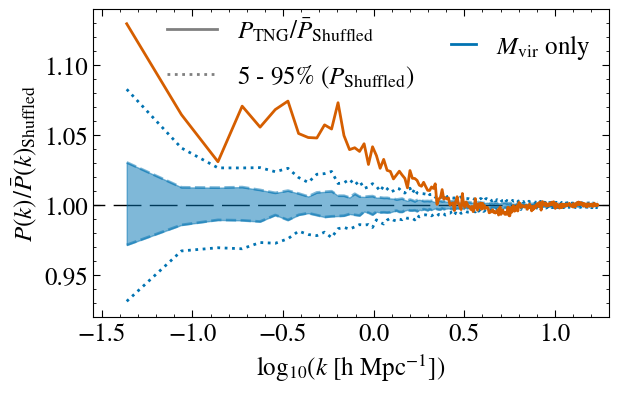

In [19]:


color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list], percentiles=[25,5], labels=[f"Shuffle {object2shuffle} {logM_name}", f"4 percentiles", f"100 percentiles", "Shuffled quartiles"], ratio_ylabel_list=["Shuffled",""], return_color_leg=True, tng_shuffle_type="property")#, bbox_to_anchor_color = (0,0.8))
#plt.ylim(0.97,1.06)
ax = plt.gca()
 
# leg = ax.legend(handles=color_leg, labels=["Shuffle by"+ "\n" + r"$M\rm_{vir}$ only"], loc='upper left', bbox_to_anchor=(0.1, 1))
# ax.add_artist(leg)
# leg = ax.legend(handles=color_leg[1:2], labels=[fr"$M_{{\mathrm{{sat}}}}$ (4)"], loc='upper left', bbox_to_anchor=(0.6, 0.85
#                                                                                             ))
# ax.add_artist(leg)
# leg = ax.legend(handles=color_leg[2:], labels=[fr"various"], loc='upper left', bbox_to_anchor=(0.6, 0.73))
# ax.add_artist(leg)
# #ax.annotate(r"M$\rm_{vir}$ &",(0.9,0.1), xycoords="axes fraction")
# #ax.annotate(r"Split by $\rm V_{max}/r_{max}$ (6)", (0.95,0.9), xycoords="axes fraction", ha="right")
# ax.annotate(r"Split by", (0.9,0.85), xycoords="axes fraction", ha="right")
solid_line = Line2D([],[],color="grey", linestyle="solid")
leg = ax.legend(handles=[solid_line], labels=[r"$P_{\rm TNG}/\bar{P}_{\rm Shuffled}$"], loc='upper left', bbox_to_anchor=(0.1, 1.05))
ax.add_artist(leg)
dot_line = Line2D([],[],color="grey", linestyle="dotted")
leg = ax.legend(handles=[dot_line], labels=[r"5 - 95% $(P_{\rm Shuffled})$"], loc='upper left', bbox_to_anchor=(0.1, 0.9))
ax.add_artist(leg)
leg = ax.legend(handles=color_leg, labels=[r"$M\rm_{vir}$ only"], loc='upper left', bbox_to_anchor=(0.65, 1), handlelength=1)
ax.add_artist(leg)

#ax.annotate(r"$\rm \widetilde{V}_{max}$", (0.65,0.73), xycoords="figure fraction")
# leg = ax.legend(handles=color_leg[1:2], labels=[rf"$M_{{\rm sat}}$ (4)"], loc='upper left', bbox_to_anchor=(0.65, 0.85), handlelength=1)
# ax.add_artist(leg)
# leg = ax.legend(handles=color_leg[2:], labels=[rf"various"], loc='upper left', bbox_to_anchor=(0.65, 0.73), handlelength=1)
# ax.add_artist(leg)

#ax.annotate(f"logM11-13.8", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")

plt.ylim(0.92,1.14)
plt.legend()
#plt.savefig("figures/logM11-13.8_shuffled.pdf", format="pdf", bbox_inches="tight")
